In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
#from torchvision import datasets
#from torch.utils.data import DataLoader
#from torchvision import transforms
from utilsCPD import *
import matplotlib.pyplot as plt
from SWCPD import BaseDetector as SWDCP

In [9]:
#detection_delay(set(detector.change_points['loc']),set(GroundTruth))
def detection_delay(gt, pred):
    """Compute detection delay for each predicted CP.
    
    Args:
        T (set): Ground truth CPs (annotations).
        X (set): Predicted CPs.

    Returns:
        delays (dict): {prediction: detection delay}
        avg_delay (float): Mean detection delay
    """
    T = set(gt)
    X = set(pred)
    delays = {}
    for x in X:
        if T:  # Ensure T is not empty
            closest_t = min(T, key=lambda t: abs(x - t))  # Find closest annotation
            delays[x] = abs(x - closest_t)  # Compute delay
    
    avg_delay = np.mean(list(delays.values())) if delays else 0  # Mean delay
    return delays, avg_delay


def f_measure(annotations, predictions, margin=5, alpha=0.5, return_PR=False):
    """Compute the F-measure based on human annotations.

    annotations : dict from user_id to iterable of CP locations
    predictions : iterable of predicted CP locations
    alpha : value for the F-measure, alpha=0.5 gives the F1-measure
    return_PR : whether to return precision and recall too

    Remember that all CP locations are 0-based!

    >>> f_measure({1: [10, 20], 2: [11, 20], 3: [10], 4: [0, 5]}, [10, 20])
    1.0
    >>> f_measure({1: [], 2: [10], 3: [50]}, [10])
    0.9090909090909091
    >>> f_measure({1: [], 2: [10], 3: [50]}, [])
    0.8
    """
    # ensure 0 is in all the sets
    Tks = {k + 1: set(annotations[uid]) for k, uid in enumerate(annotations)}
    for Tk in Tks.values():
        Tk.add(0)

    X = set(predictions)
    X.add(0)

    Tstar = set()
    for Tk in Tks.values():
        for tau in Tk:
            Tstar.add(tau)

    K = len(Tks)

    P = len(true_positives(Tstar, X, margin=margin)) / len(X)

    TPk = {k: true_positives(Tks[k], X, margin=margin) for k in Tks}
    R = 1 / K * sum(len(TPk[k]) / len(Tks[k]) for k in Tks)

    TP = false_positives(Tstar,X,margin=margin)
    F = P * R / (alpha * R + (1 - alpha) * P)
    if return_PR:
        return F, P, R
    return F, auc([0,R,1.0],[1.0,P,0]),len(false_positives(Tstar,X,margin=margin))



def true_positives(T, X, margin=5):
    """Compute true positives without double counting

    >>> true_positives({1, 10, 20, 23}, {3, 8, 20})
    {1, 10, 20}
    >>> true_positives({1, 10, 20, 23}, {1, 3, 8, 20})
    {1, 10, 20}
    >>> true_positives({1, 10, 20, 23}, {1, 3, 5, 8, 20})
    {1, 10, 20}
    >>> true_positives(set(), {1, 2, 3})
    set()
    >>> true_positives({1, 2, 3}, set())
    set()
    """
    # make a copy so we don't affect the caller
    X = set(list(X))
    TP = set()
    for tau in T:
        close = [(abs(tau - x), x) for x in X if abs(tau - x) <= margin]
        close.sort()
        if not close:
            continue
        dist, xstar = close[0]
        TP.add(tau)
        X.remove(xstar)
    return TP

# def false_positives(T, X, margin=5):
#     """Returns a set of false positives (incorrectly predicted CPs)."""
#     TP = true_positives(T, X, margin)
#     return X - TP  # FP = All Predictions - True Positives
def false_positives(T, X, margin=5):
    """Compute false positives (predictions that don't match any true CPs within margin)."""
    FP = set()
    for x in X:
        if not any(abs(x - t) <= margin for t in T):  # No match within margin
            FP.add(x)
    return FP

#### Add Grid Search for reviewer as well, 

### Add metrics False change rate, Detection delay, Error rate, detection accuracy

[[1.57454012 0.2        0.2        1.93199394 0.2        2.15071431
  0.2        0.2        0.2        0.2        0.2        0.2
  0.2        0.2        0.2        0.2        0.2        0.2
  0.2        0.2       ]
 [3.3731986  0.2        0.2        3.28798846 0.2        3.50673295
  0.2        0.2        0.2        0.2        0.2        0.2
  0.2        0.2        0.2        0.2        0.2        0.2
  0.2        0.2       ]]


<Axes: >

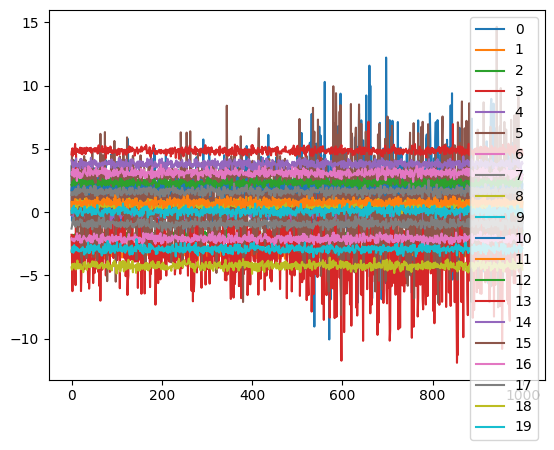

In [10]:
import numpy as np

def make_dynamic_blobs_var(n_samples, base_center, n_clusters, varying_features, 
                           base_cluster_std=1.0, std_variation_range=(0.5, 2.0), 
                           random_state=None):
    """
    Generate synthetic data where the variance of certain features varies across clusters.
    
    Parameters:
        n_samples: int
            Total number of samples.
        base_center: array-like
            The center of the first cluster. Shape: (n_features,).
        n_clusters: int
            Number of clusters to generate.
        varying_features: list of int
            Indices of features where variance should change across clusters.
        base_cluster_std: float
            Base standard deviation of clusters.
        std_variation_range: tuple
            Range (min, max) for random uniform scaling of the base standard deviation.
        random_state: int or None
            Random seed for reproducibility.
    
    Returns:
        X: ndarray of shape (n_samples, n_features)
            The generated samples.
        y: ndarray of shape (n_samples,)
            The integer labels for cluster membership.
        cluster_stds: ndarray of shape (n_clusters, n_features)
            The standard deviations used for each cluster.
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    n_features = len(base_center)
    samples_per_cluster = n_samples // n_clusters
    remainder = n_samples % n_clusters

    # Keep the same center for all clusters
    centers = np.tile(base_center, (n_clusters, 1))

    # Generate different standard deviations per cluster
    cluster_stds = np.full((n_clusters, n_features), base_cluster_std, dtype=float)
    
    for cluster_idx in range(n_clusters):
        for feature in varying_features:
            # Randomly scale the standard deviation for this cluster and feature
            cluster_stds[cluster_idx, feature] += np.random.uniform(*std_variation_range)#*np.random.uniform(*std_variation_range)
            if cluster_idx>0:
                cluster_stds[cluster_idx, feature] +=cluster_stds[cluster_idx-1,feature]
    
    # Generate points for each cluster
    X = []
    y = []
    for cluster_idx in range(n_clusters):
        cluster_size = samples_per_cluster + (1 if cluster_idx < remainder else 0)
        cluster_points = np.random.normal(
            loc=centers[cluster_idx],  # Keep the center fixed
            scale=cluster_stds[cluster_idx],  # Use varying standard deviation
            size=(cluster_size, n_features)
        )
        X.append(cluster_points)
        y.extend([cluster_idx] * cluster_size)
    
    X = np.vstack(X)
    y = np.array(y)
    
    return X.astype(np.float32), y, cluster_stds




base_center = list(np.random.uniform(-5,5,20))  # 2D example
n_clusters = 2
n_samples = 1000
varying_features = [0,5,3]  # Only vary the variance of the second feature
base_cluster_std = 0.2
std_variation_range = (1.0, 2.0)

X, y, cluster_stds = make_dynamic_blobs_var(n_samples, base_center, n_clusters, 
                                            varying_features, base_cluster_std, 
                                            std_variation_range, random_state=42)
print(cluster_stds)
fig, ax = plt.subplots()
pd.DataFrame(X).plot(ax=ax,legend=True)

In [11]:
METRICS_SWD = {}
for id,i in enumerate(range(1)):
    print(id)
    METRICS_SWD[id]  = {}
    df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
    print(GroundTruth)
    #100-100
    #50-50 for ExpPLot 
    detector = SWDCP(data=df,window_length=50,max_history=50,significance=0.01)
    print(detector.device)
    detector.process_dataloader(p=4,n_theta=1000,explanations=False,exp_param={'num_features_to_remove':3,'max_parameter':True,"q":0.95})
    METRICS_SWD[id]['F1'] =f_measure({'0':GroundTruth},detector.change_points['loc'],margin=20)
    METRICS_SWD[id]['Covering'] = covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0])
    print(METRICS_SWD[id])

0
[500]
cpu


 53%|█████▎    | 505/951 [00:01<00:01, 322.92it/s]

Change detected at: 518 
Initiate new segment
Change detected at: 520 
Initiate new segment


100%|██████████| 951/951 [00:03<00:00, 244.02it/s]

{'F1': (0.8, 0.8333333333333333, 0), 'Covering': 0.9626254826254826}


In [91]:
base_center = list(np.random.uniform(-5,5,50))#,0,0,0,0]  # Base center for the first cluster
base_cluster_std = 0.2
std_variation_range = (1.0, 2.0)

In [100]:
random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 3
n_samples = 1500
varying_features = [0,5,3,10,15,20]

SIGMA = [(0.5,1.0),(0.7,1.2),(1.2,1.7)]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[],'DD':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs_var(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            base_cluster_std=base_cluster_std,
            std_variation_range=sigma,
            random_state=rs
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        print(GroundTruth)
        detector = SWDCP(data=df,window_length=50,max_history=50,significance=0.01)
        print(detector.device)
        detector.process_dataloader(p=4,n_theta=1000,explanations=False)
        TMP = {}
        for margin in [5,10,20]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])

    
RUN_STATS


2020 (0.5, 1.0)
[ 500 1000]
cpu


 35%|███▍      | 507/1451 [00:02<00:04, 191.87it/s]

Change detected at: 523 
Initiate new segment


100%|██████████| 1451/1451 [00:07<00:00, 191.82it/s]


2021 (0.5, 1.0)
[ 500 1000]
cpu


...

2024 (1.2, 1.7)
[ 500 1000]
cpu


 34%|███▎      | 487/1451 [00:02<00:05, 192.50it/s]

Change detected at: 507 
Initiate new segment


100%|██████████| 1451/1451 [00:07<00:00, 191.51it/s]


{'(0.5, 1.0)': {'F1 & AUC & FP': [{'5': (0.4, 0.4166666666666667, 1),
    '10': (0.4, 0.4166666666666667, 1),
    '20': (0.4, 0.4166666666666667, 1)},
   {'5': (0.6666666666666666, 0.6666666666666666, 1),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (0.28571428571428575, 0.29166666666666663, 3),
    '10': (0.5714285714285715, 0.5833333333333334, 2),
    '20': (0.5714285714285715, 0.5833333333333334, 2)},
   {'5': (0.3333333333333333, 0.3333333333333333, 2),
    '10': (0.3333333333333333, 0.3333333333333333, 2),
    '20': (0.3333333333333333, 0.3333333333333333, 2)},
   {'5': (0.3333333333333333, 0.3333333333333333, 2),
    '10': (0.6666666666666666, 0.6666666666666666, 0),
    '20': (0.6666666666666666, 0.6666666666666666, 0)}],
  'Covering': [0.648264557088367,
   0.9802290817317025,
   0.9575643205687265,
   0.6456187592946676,
   0.659767491184814],
  'DD': [23.0, 7.5, 19.666666666666668, 31.5, 9.0]},
 '(0.7, 1.2)': {'F1 & AUC & FP': [{'5': (0.4, 0.4166666666666667, 1

In [94]:
k1,k2,k3 = RUN_STATS.keys()

### AUC

In [128]:
#RUN_STATS['(0.5, 1.0)']['F1 & AUC']


grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}


for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k3,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))

#### 
print("########## Fales Positives ############")

grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}


for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k3,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))

5 0.41 0.14
10 0.6 0.23
20 0.6 0.23
5 0.44 0.12
10 0.65 0.23
20 0.73 0.21
5 0.42 0.13
10 0.57 0.18
20 0.78 0.15
########## Fales Positives ############
5 1.8 1 3
10 1.0 0 2
20 1.0 0 2
5 1.4 1 3
10 0.8 0 2
20 0.6 0 2
5 1.6 1 3
10 1.2 0 2
20 0.4 0 2


In [111]:
key_dict = list(RUN_STATS.keys())

In [126]:
print('COVERING')
for i in range(3):
    print(key_dict[i],np.mean(RUN_STATS[key_dict[i]]['Covering']),np.std(RUN_STATS[key_dict[i]]['Covering']))
print('DD')
for i in range(3):
    print(key_dict[i],np.mean(RUN_STATS[key_dict[i]]['DD']),np.min(RUN_STATS[key_dict[i]]['DD']),np.max(RUN_STATS[key_dict[i]]['DD']))

COVERING
(0.5, 1.0) 0.7782888419736557 0.1558682352179693
(0.7, 1.2) 0.7799727622879218 0.15446895249641127
(1.2, 1.7) 0.780690064778075 0.1535862622643671
DD
(0.5, 1.0) 18.133333333333333 7.5 31.5
(0.7, 1.2) 14.833333333333334 7.0 21.0
(1.2, 1.7) 13.966666666666665 7.0 20.0




| jump interval| $\tau=5$ | $\tau=10$ | $\tau=20$ |
|-------------|----------|-----------|-----------|
| (0.5,1.0)        | 0.41 ± 0.14   | 0.6 ± 0.23  | 0.6 ± 0.23 |
| (0.7,1.2)        | 0.44 ± 0.12  | 0.65± 0.23  | 0.73± 0.21   |
| (1.2,1.7)       | 0.42 ± 0.13 | 0.57 ± 0.18  | 0.78 ± 0.15  |

| jump interval| $\tau=5$ | $\tau=10$ | $\tau=20$ |
|-------------|----------|-----------|-----------|
| (0.5,1.0)        | 1.8 (1;3)  | 1.0 (0;2)  | 1.0 (0;0)|
| (0.7,1.2)        | 1.4 (1;3) | 0.8 (0;2) | 0.6  (0;0)  |
| (1.2,1.7)       | 1.6 (1;3) | 1.2 (0;2) | 0.4 (0;2) |

## Detection Delay

| jump interval |DD (min;max)|
|-------------|----------|
| (0.5,1.0)          | 18 (7.5;31.5) | 
| (0.7,1.2)        | 14.8 (7;21) | 
|    (1.2,1.7)    | 14 (7.0;20) |

### Other distributions

In [12]:
import numpy as np

def make_dynamic_blobs(n_samples, base_center, n_clusters, varying_features, 
                       cluster_std=1.0, center_offset_range=(-5, 5), 
                       distribution="normal", random_state=None):
    """
    Generate synthetic data with dynamic centers and optional non-Gaussian distributions.
    
    Parameters:
        n_samples: int
            Total number of samples.
        base_center: array-like
            The center of the first cluster. Shape: (n_features,).
        n_clusters: int
            Number of clusters to generate.
        varying_features: list of int
            Indices of features that should vary across clusters.
        cluster_std: float
            Standard deviation of clusters.
        center_offset_range: tuple
            Range (min, max) for random uniform offsets added to the base center for varying features.
        distribution: str
            Distribution type: "normal", "uniform", "laplace", "exponential", "beta", "gamma".
        random_state: int or None
            Random seed for reproducibility.
    
    Returns:
        X: ndarray of shape (n_samples, n_features)
            The generated samples.
        y: ndarray of shape (n_samples,)
            The integer labels for cluster membership.
        centers: ndarray of shape (n_clusters, n_features)
            The centers of the clusters.
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    n_features = len(base_center)
    samples_per_cluster = n_samples // n_clusters
    remainder = n_samples % n_clusters

    # Generate cluster centers
    centers = [np.array(base_center, dtype=float)]
    for _ in range(1, n_clusters):
        new_center = centers[0].copy()  # Start with the base center
        for feature in varying_features:
            new_center[feature] += np.random.uniform(*center_offset_range)
        centers.append(new_center)
    centers = np.array(centers)
    
    # Generate points for each cluster with the chosen distribution
    X = []
    y = []
    
    for cluster_idx, center in enumerate(centers):
        cluster_size = samples_per_cluster + (1 if cluster_idx < remainder else 0)
        
        if distribution == "normal":
            cluster_points = np.random.normal(loc=center, scale=cluster_std, size=(cluster_size, n_features))
        
        elif distribution == "uniform":
            cluster_points = np.random.uniform(low=center - cluster_std, high=center + cluster_std, size=(cluster_size, n_features))
        
        elif distribution == "laplace":
            cluster_points = np.random.laplace(loc=center, scale=cluster_std, size=(cluster_size, n_features))
        
        elif distribution == "exponential":
            cluster_points = np.random.exponential(scale=cluster_std, size=(cluster_size, n_features)) + center
        
        elif distribution == "beta":
            cluster_points = np.random.beta(a=2, b=5, size=(cluster_size, n_features)) * cluster_std + center  # Shape parameters (2,5) can be tuned
        
        elif distribution == "gamma":
            cluster_points = np.random.gamma(shape=2, scale=cluster_std, size=(cluster_size, n_features)) + center  # Shape=2 can be adjusted
        
        else:
            raise ValueError(f"Unsupported distribution: {distribution}")
        
        X.append(cluster_points)
        y.extend([cluster_idx] * cluster_size)
    
    X = np.vstack(X)
    y = np.array(y)
    
    return X.astype(np.float32), y, centers


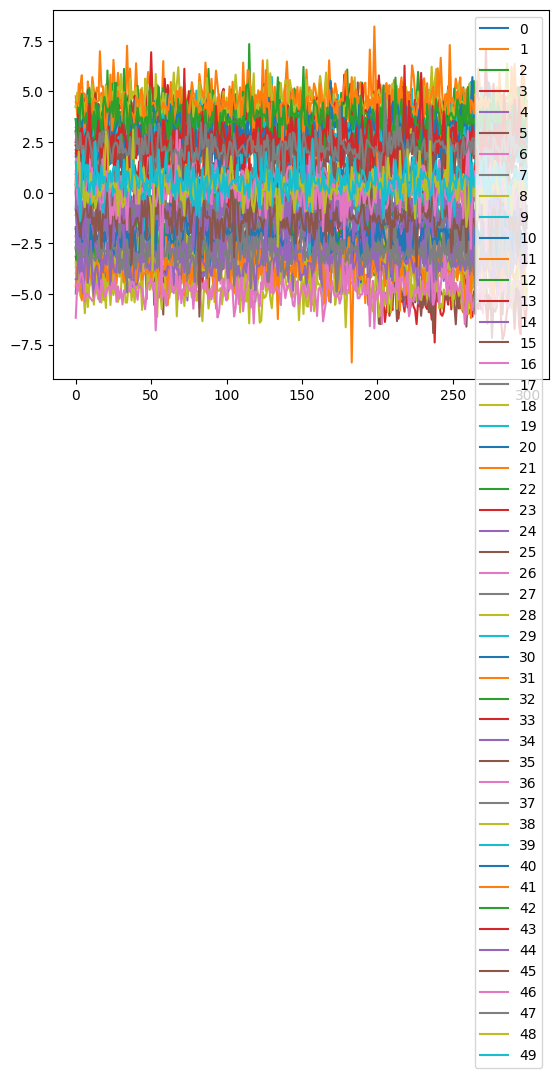

In [24]:
# Base center for the clusters
base_center = list(np.random.uniform(-5, 5, 50))  
n_clusters = 3
n_samples = 300
varying_features = [0, 5, 3]  

# Generate dataset with Laplace distribution (heavy tails)
X, y, centers = make_dynamic_blobs(
    n_samples=n_samples, 
    base_center=base_center, 
    n_clusters=n_clusters, 
    varying_features=varying_features, 
    cluster_std=0.5, 
    center_offset_range=(-3, 3), 
    distribution="laplace",
    random_state=42
)

# Plot the results
fig, ax = plt.subplots()
pd.DataFrame(X).plot(ax=ax, legend=True)
plt.show()


### Exponential

In [25]:
random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 3
n_samples = 1500
varying_features = [0,5,3]

SIGMA = [0.1,0.5,1]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[], 'DD':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=sigma, 
            center_offset_range=(-3, 3), 
            random_state=rs, distribution='exponential'
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        print(GroundTruth)
        detector = SWDCP(data=df,window_length=50,max_history=50,significance=0.05)
        print(detector.device)
        detector.process_dataloader(p=2,n_theta=5000,explanations=False)
        TMP = {}
        for margin in [5,10,20]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])
        #print(RUN_STATS)
    #METRICS.append(RUN_STATS)
RUN_STATS


2020 0.1
[ 500 1000]
cpu


  0%|          | 0/1451 [00:00<?, ?it/s]

 32%|███▏      | 460/1451 [00:07<00:15, 64.92it/s]

Change detected at: 501 
Initiate new segment


 66%|██████▌   | 959/1451 [00:14<00:07, 68.97it/s]

...

2024 1
[ 500 1000]
cpu


 68%|██████▊   | 987/1451 [00:13<00:05, 81.85it/s]

Change detected at: 1022 
Initiate new segment


100%|██████████| 1451/1451 [00:18<00:00, 76.75it/s]


{'0.1': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)}],
  'Covering': [0.9973373253493014,
   0.9946826029216468,
   0.9960092987994794,
   0.9960093041009613,
   0.9960093041009613],
  'DD': [np.float64(1.0),
   np.float64(2.0),
   np.float64(1.5),
   np.float64(1.5),
   np.float64(1.5)]},
 '0.5': {'F1 & AUC & FP': [{'5': (0.3333333333333333, 0.3333333333333333, 2),
    '10': (0.6666666666666666, 0.6666666666666666, 1),
    '20': (1.0, 1.0, 0)},
   {'5': (0.3333333333333333, 0.3333333333333333, 2),
    '10': (0.3333333333333333, 0.3333333333333333, 2),
    '20': (1.0, 1.0, 0)},
   {'5': (0.3333333333333333, 0.3333333333333333, 2),
    '10': (0.6666666666666666, 0.666666666666666

In [30]:
#RUN_STATS['(0.5, 1.0)']['F1 & AUC']
k1,k2,k3 = RUN_STATS.keys()

grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}


for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k3,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))

#### 
print("########## Fales Positives ############")

grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}


for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k3,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))

5 1.0 0.0
10 1.0 0.0
20 1.0 0.0
5 0.33 0.0
10 0.6 0.13
20 0.93 0.13
5 0.47 0.1
10 0.47 0.1
20 0.55 0.17
########## Fales Positives ############
5 0.0 0 0
10 0.0 0 0
20 0.0 0 0
5 2.0 2 2
10 1.2 1 2
20 0.2 0 1
5 0.8 0 1
10 0.8 0 1
20 0.6 0 1


In [23]:
key_dict = list(RUN_STATS.keys())
print('COVERING')
for i in range(3):
    print(key_dict[i],np.mean(RUN_STATS[key_dict[i]]['Covering']),np.std(RUN_STATS[key_dict[i]]['Covering']))
print('DD')
for i in range(3):
    print(key_dict[i],np.mean(RUN_STATS[key_dict[i]]['DD']),np.min(RUN_STATS[key_dict[i]]['DD']),np.max(RUN_STATS[key_dict[i]]['DD']))

COVERING
0.1 0.9973373253493014 0.0
0.5 0.9799828965662536 0.00516975181164438
1 0.8987188057217524 0.12293116959065502
DD
0.1 1.0 1.0 1.0
0.5 7.6 5.5 11.0
1 15.6 10.5 21.333333333333332




| $\lambda$ | $\tau=5$ | $\tau=10$ | $\tau=20$ |
|-------------|----------|-----------|-----------|
| 0.1       | 1.0 ± 0.0   | 1.0 ± 0.0  | 1 ± 0.23 |
| 0.5        | 0.33 ± 0.0  | 0.6± 0.13  | 0.93± 0.13   |
| 1       | 0.47 ± 0.1 | 0.47 ± 0.1  | 0.55 ± 0.17  |

| $\lambda$| $\tau=5$ | $\tau=10$ | $\tau=20$ |
|-------------|----------|-----------|-----------|
| 0.1        | 0 (0;0)  | 0 (0;0)  | 0 (0;0)|
| 0.5        | 2 (2;2) | 1.2 (1;2) | 0.2  (0;1)  |
| 1      | 0.8 (0;1) | 0.8 (0;1) | 0.6 (0;1) |

## Detection Delay

| jump interval |DD (min;max)|
|-------------|----------|
| 0.1          | 1.5 (1;2) | 
| 0.5        | 14.8 (11;18.5) | 
|  1    | 16.6 (0.0;22) |

### Beta

In [137]:

random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 3
n_samples = 1500
varying_features = [0,5,3]

SIGMA = [0.1,0.5,1]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[],'DD':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=sigma, 
            center_offset_range=(-3, 3), 
            random_state=rs, distribution='beta'
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        print(GroundTruth)
        detector = SWDCP(data=df,window_length=50,max_history=50,significance=0.05)
        print(detector.device)
        detector.process_dataloader(p=2,n_theta=5000,explanations=False)
        TMP = {}
        for margin in [5,10,20]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])
        #print(RUN_STATS)
    #METRICS.append(RUN_STATS)
RUN_STATS


2020 0.1
[ 500 1000]
cpu


  0%|          | 0/1451 [00:00<?, ?it/s]

 32%|███▏      | 470/1451 [00:04<00:08, 115.62it/s]

Change detected at: 501 
Initiate new segment


 66%|██████▋   | 962/1451 [00:08<00:04, 121.42it/s]

...

Change detected at: 506 
Initiate new segment


 67%|██████▋   | 965/1451 [00:08<00:04, 119.98it/s]

Change detected at: 1002 
Initiate new segment


100%|██████████| 1451/1451 [00:12<00:00, 117.83it/s]


{'0.1': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)}],
  'Covering': [0.9973373253493014,
   0.9973373253493014,
   0.9973373253493014,
   0.9973373253493014,
   0.9973373253493014],
  'DD': [1.0, 1.0, 1.0, 1.0, 1.0]},
 '0.5': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)}],
  'Covering': [0.9973373253493014,
   0.9946826029216468,
   0.9960092987994794,
   0.99600930410096

In [138]:
#RUN_STATS['(0.5, 1.0)']['F1 & AUC']


grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}


for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k3,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))

#### 
print("########## Fales Positives ############")

grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}


for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k3,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))

5 1.0 0.0
10 1.0 0.0
20 1.0 0.0
5 1.0 0.0
10 1.0 0.0
20 1.0 0.0
5 0.93 0.13
10 1.0 0.0
20 1.0 0.0
########## Fales Positives ############
5 0.0 0 0
10 0.0 0 0
20 0.0 0 0
5 0.0 0 0
10 0.0 0 0
20 0.0 0 0
5 0.2 0 1
10 0.0 0 0
20 0.0 0 0


In [139]:
key_dict = list(RUN_STATS.keys())
print('COVERING')
for i in range(3):
    print(key_dict[i],np.mean(RUN_STATS[key_dict[i]]['Covering']),np.std(RUN_STATS[key_dict[i]]['Covering']))
print('DD')
for i in range(3):
    print(key_dict[i],np.mean(RUN_STATS[key_dict[i]]['DD']),np.min(RUN_STATS[key_dict[i]]['DD']),np.max(RUN_STATS[key_dict[i]]['DD']))

COVERING
0.1 0.9973373253493014 0.0
0.5 0.99600956705447 0.0008394970053005233
1 0.9917767084080953 0.002422707889012768
DD
0.1 1.0 1.0 1.0
0.5 1.5 1.0 2.0
1 3.1 1.5 4.0



| noise | $\tau=5$ | $\tau=10$ | $\tau=20$ |
|-------------|----------|-----------|-----------|
| 0.1       | 1.0 ± 0.0   | 1.0 ± 0.0  | 1 ± 0.0 |
| 0.5       | 1.0 ± 0.0   | 1.0 ± 0.0  | 1 ± 0.0 |
| 1       | 0.93 ± 0.13   | 1.0 ± 0.0  | 1 ± 0.0 |

| noise| $\tau=5$ | $\tau=10$ | $\tau=20$ |
|-------------|----------|-----------|-----------|
| 0.1        | 0 (0;0)  | 0 (0;0)  | 0 (0;0)|
| 0.5        | 0 (0;0)  | 0 (0;0)  | 0 (0;0)|
| 1      |   0.2 (0;1)  | 0 (0;0)  | 0 (0;0)|

## Detection Delay

| noise |DD (min;max)|
|-------------|----------|
| 0.1          | 1.0 (1;1) | 
| 0.5        | 1.5 (1;2) | 
|  1    | 3.1 (1.5;4.0) |

### Laplace

In [84]:

random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 3
n_samples = 1500
varying_features = [0,5,3]

SIGMA = [0.1,0.5,1]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC':[],'Covering':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=sigma, 
            center_offset_range=(-3, 3), 
            random_state=rs, distribution='laplace'
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        print(GroundTruth)
        detector = SWDCP(data=df,window_length=50,max_history=50,significance=0.05)
        print(detector.device)
        detector.process_dataloader(p=2,n_theta=5000,explanations=False)
        TMP = {}
        for margin in [5,10,20]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        #print(RUN_STATS)
    #METRICS.append(RUN_STATS)
RUN_STATS


2020 0.1
[ 500 1000]
cpu


 33%|███▎      | 474/1451 [00:03<00:07, 130.89it/s]

Change detected at: 501 
Initiate new segment


 67%|██████▋   | 971/1451 [00:07<00:03, 126.78it/s]

Change detected at: 1001 
Initiate new segment


...

2024 1
[ 500 1000]
cpu


 68%|██████▊   | 982/1451 [00:08<00:03, 133.84it/s]

Change detected at: 1013 
Initiate new segment


100%|██████████| 1451/1451 [00:11<00:00, 128.05it/s]


{'0.1': {'F1 & AUC': [{'5': (1.0, 1.0), '10': (1.0, 1.0), '20': (1.0, 1.0)},
   {'5': (1.0, 1.0), '10': (1.0, 1.0), '20': (1.0, 1.0)},
   {'5': (1.0, 1.0), '10': (1.0, 1.0), '20': (1.0, 1.0)},
   {'5': (1.0, 1.0), '10': (1.0, 1.0), '20': (1.0, 1.0)},
   {'5': (1.0, 1.0), '10': (1.0, 1.0), '20': (1.0, 1.0)}],
  'Covering': [0.9973373253493014,
   0.9973373253493014,
   0.9973373253493014,
   0.9973373253493014,
   0.9973373253493014]},
 '0.5': {'F1 & AUC': [{'5': (0.6666666666666666, 0.6666666666666666),
    '10': (1.0, 1.0),
    '20': (1.0, 1.0)},
   {'5': (0.3333333333333333, 0.3333333333333333),
    '10': (0.6666666666666666, 0.6666666666666666),
    '20': (1.0, 1.0)},
   {'5': (0.6666666666666666, 0.6666666666666666),
    '10': (1.0, 1.0),
    '20': (1.0, 1.0)},
   {'5': (0.6666666666666666, 0.6666666666666666),
    '10': (1.0, 1.0),
    '20': (1.0, 1.0)},
   {'5': (0.5714285714285715, 0.5833333333333334),
    '10': (0.8571428571428571, 0.875),
    '20': (0.8571428571428571, 0.875)}

In [85]:
RUN_STATS['0.1']['F1 & AUC']

grouped = {}

for d in RUN_STATS['0.1']['F1 & AUC']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

print(0.1,pd.DataFrame(grouped).describe())


for d in RUN_STATS['0.5']['F1 & AUC']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

print(0.5,pd.DataFrame(grouped).describe())



for d in RUN_STATS['1']['F1 & AUC']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

print(1,pd.DataFrame(grouped).describe())

0.1          5   10   20
count  5.0  5.0  5.0
mean   1.0  1.0  1.0
std    0.0  0.0  0.0
min    1.0  1.0  1.0
25%    1.0  1.0  1.0
50%    1.0  1.0  1.0
75%    1.0  1.0  1.0
max    1.0  1.0  1.0
0.5                5         10         20
count  10.000000  10.000000  10.000000
mean    0.791667   0.954167   0.987500
std     0.239759   0.108387   0.039528
min     0.333333   0.666667   0.875000
25%     0.666667   1.000000   1.000000
50%     0.833333   1.000000   1.000000
75%     1.000000   1.000000   1.000000
max     1.000000   1.000000   1.000000
1                5         10         20
count  15.000000  15.000000  15.000000
mean    0.641667   0.772222   0.950000
std     0.292855   0.291610   0.097336
min     0.291667   0.291667   0.666667
25%     0.333333   0.541667   0.937500
50%     0.666667   1.000000   1.000000
75%     1.000000   1.000000   1.000000
max     1.000000   1.000000   1.000000


In [2]:
import numpy as np

def make_dynamic_blobs(n_samples, base_center, n_clusters, varying_features, 
                       cluster_std=1.0, center_offset_range=(-5, 5), 
                       distribution="normal", random_state=None):
    """
    Generate synthetic data with dynamic centers and feature-wise distributions.
    
    Parameters:
        n_samples: int
            Total number of samples.
        base_center: array-like, shape (n_features,)
            Center of the base cluster.
        n_clusters: int
            Number of clusters to generate.
        varying_features: list of int
            Indices of features that vary across clusters.
        cluster_std: float or array-like
            Std dev for distributions. Can be a scalar or array of shape (n_features,).
        center_offset_range: tuple
            Uniform offset range applied to varying features.
        distribution: str or list of str
            Single distribution name or list of length n_features specifying distribution per feature.
        random_state: int or None
            Seed for reproducibility.
    
    Returns:
        X: ndarray (n_samples, n_features)
        y: ndarray (n_samples,)
        centers: ndarray (n_clusters, n_features)
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    base_center = np.array(base_center, dtype=float)
    n_features = len(base_center)
    
    if isinstance(distribution, str):
        distribution = [distribution] * n_features
    elif isinstance(distribution, list):
        if len(distribution) != n_features:
            raise ValueError("Length of distribution list must match number of features.")

    if np.isscalar(cluster_std):
        cluster_std = np.full(n_features, cluster_std)

    samples_per_cluster = n_samples // n_clusters
    remainder = n_samples % n_clusters

    # Generate cluster centers
    centers = [base_center.copy()]
    for _ in range(1, n_clusters):
        new_center = base_center.copy()
        for feat in varying_features:
            new_center[feat] += np.random.uniform(*center_offset_range)
        centers.append(new_center)
    centers = np.array(centers)

    # Generate data
    X = []
    y = []

    for cluster_idx, center in enumerate(centers):
        cluster_size = samples_per_cluster + (1 if cluster_idx < remainder else 0)
        cluster_points = np.zeros((cluster_size, n_features), dtype=np.float32)

        for feat_idx in range(n_features):
            dist = distribution[feat_idx]
            std = cluster_std[feat_idx]
            loc = center[feat_idx]

            if dist == "normal":
                vals = np.random.normal(loc=loc, scale=std, size=cluster_size)
            elif dist == "uniform":
                vals = np.random.uniform(low=loc - std, high=loc + std, size=cluster_size)
            elif dist == "laplace":
                vals = np.random.laplace(loc=loc, scale=std, size=cluster_size)
            elif dist == "exponential":
                vals = np.random.exponential(scale=std, size=cluster_size) + loc
            elif dist == "beta":
                vals = np.random.beta(a=2, b=5, size=cluster_size) * std + loc
            elif dist == "gamma":
                vals = np.random.gamma(shape=2, scale=std, size=cluster_size) + loc
            else:
                raise ValueError(f"Unsupported distribution: {dist}")

            cluster_points[:, feat_idx] = vals
        
        X.append(cluster_points)
        y.extend([cluster_idx] * cluster_size)

    return np.vstack(X), np.array(y), centers


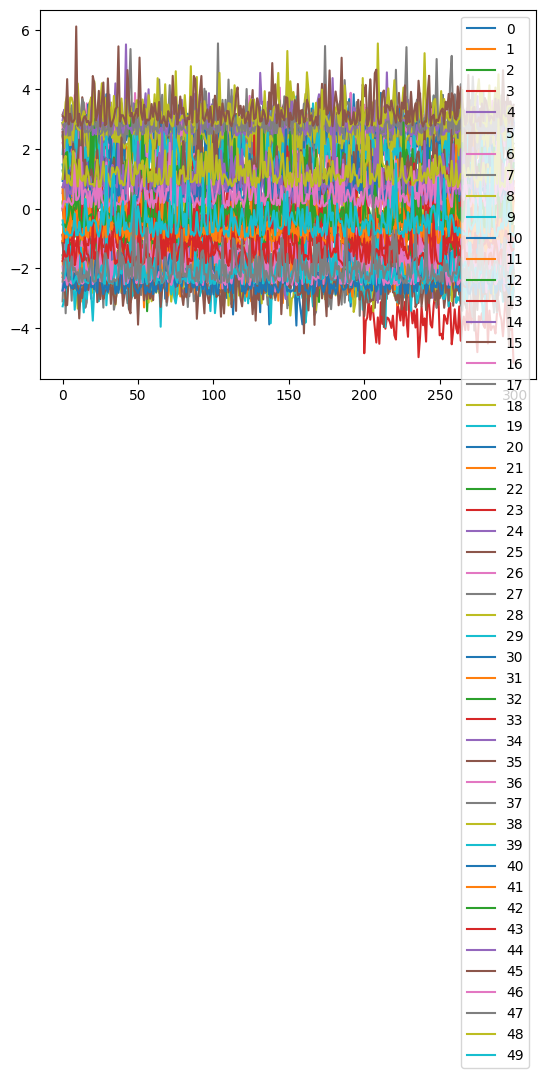

In [34]:
# Base center for the clusters
base_center = list(np.random.uniform(-3, 3, 50))  
n_clusters = 3
n_samples = 300
varying_features = [0, 5, 3]  

# Generate dataset with Laplace distribution (heavy tails)
X, y, centers = make_dynamic_blobs(
    n_samples=n_samples, 
    base_center=base_center, 
    n_clusters=n_clusters, 
    varying_features=varying_features, 
    cluster_std=0.5, 
    center_offset_range=(-3, 3), 
    distribution=["normal"] * 30 + ["exponential"] * 20,
    random_state=42
)

# Plot the results
fig, ax = plt.subplots()
pd.DataFrame(X).plot(ax=ax, legend=True)
plt.show()


In [45]:
random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 3
n_samples = 1500
varying_features = [0,25,37]

SIGMA = [0.25,0.5]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[], 'DD':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=sigma, 
            center_offset_range=(-3, 3), 
            random_state=rs, distribution=["normal"] * 30 + ["exponential"] * 20,
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        print(GroundTruth)
        detector = SWDCP(data=df,window_length=50,max_history=50,significance=0.05)
        print(detector.device)
        detector.process_dataloader(p=2,n_theta=5000,explanations=False)
        TMP = {}
        for margin in [5,10,20]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])
        #print(RUN_STATS)
    #METRICS.append(RUN_STATS)
RUN_STATS


2020 0.25
[ 500 1000]
cpu


 32%|███▏      | 468/1451 [00:07<00:14, 66.27it/s]

Change detected at: 505 
Initiate new segment


 66%|██████▌   | 960/1451 [00:14<00:08, 59.84it/s]

Change detected at: 1002 
Initiate new segment


...

Change detected at: 520 
Initiate new segment


 67%|██████▋   | 968/1451 [00:15<00:06, 71.06it/s]

Change detected at: 1009 
Initiate new segment


100%|██████████| 1451/1451 [00:22<00:00, 64.05it/s]


{'0.25': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (0.3333333333333333, 0.3333333333333333, 2),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (0.6666666666666666, 0.6666666666666666, 1),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (0.6666666666666666, 0.6666666666666666, 1),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (0.6666666666666666, 0.6666666666666666, 1),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)}],
  'Covering': [0.9907182622644735,
   0.9802219116101611,
   0.9828410723381255,
   0.9867708593932788,
   0.9854610604091985],
  'DD': [np.float64(3.5),
   np.float64(7.5),
   np.float64(6.5),
   np.float64(5.0),
   np.float64(5.5)]},
 '0.5': {'F1 & AUC & FP': [{'5': (0.3333333333333333, 0.3333333333333333, 2),
    '10': (0.6666666666666666, 0.6666666666666666, 1),
    '20': (1.0, 1.0, 0)},
   {'5': (0.3333333333333333, 0.3333333333333333, 2),
    '10': (0.3333333333333333,

In [46]:
k1,k2 = RUN_STATS.keys()


grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))




#### 
print("########## Fales Positives ############")

grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))




5 0.67 0.21
10 1.0 0.0
20 1.0 0.0
5 0.33 0.0
10 0.53 0.16
20 0.87 0.16
########## Fales Positives ############
5 1.0 0 2
10 0.0 0 0
20 0.0 0 0
5 2.0 2 2
10 1.4 1 2
20 0.4 0 1


In [43]:
key_dict = ['0.25','0.5']

In [ ]:
key_dict = ['0.25','0.5']
for i in range(2):
    print(key_dict[i],np.mean(RUN_STATS[key_dict[i]]['DD']),np.min(RUN_STATS[key_dict[i]]['DD']),np.max(RUN_STATS[key_dict[i]]['DD']))

0.25 5.6 3.5 7.5
0.5 14.9 10.5 20.5


### More drifted features and shorter clusters

In [18]:
random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 10
n_samples = 1500
varying_features = [0,25,37,2,20,45,1,4,5,6,7,8,10,32,21]

SIGMA = [0.75]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[], 'DD':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=sigma, 
            center_offset_range=(-3, 3), 
            random_state=rs, distribution=["normal"] * 0 + ["exponential"] * 50,
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        print(GroundTruth)
        detector = SWDCP(data=df,window_length=50,max_history=50,significance=0.05,use_cuda=False)
        print(detector.device)
        detector.process_dataloader(p=2,n_theta=5000,explanations=False)
        TMP = {}
        for margin in [5,10,20]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])
        #print(RUN_STATS)
    #METRICS.append(RUN_STATS)
RUN_STATS


2020 0.75
[ 150  300  450  600  750  900 1050 1200 1350]
cpu


  9%|▊         | 124/1451 [00:01<00:11, 117.38it/s]

Change detected at: 159 
Initiate new segment


 19%|█▉        | 275/1451 [00:02<00:09, 120.18it/s]

Change detected at: 306 
Initiate new segment


...

Change detected at: 1204 
Initiate new segment


 91%|█████████▏| 1326/1451 [00:11<00:01, 107.83it/s]

Change detected at: 1356 
Initiate new segment


100%|██████████| 1451/1451 [00:12<00:00, 112.96it/s]


{'0.75': {'F1 & AUC & FP': [{'5': (0.4000000000000001, 0.39999999999999997, 6),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (0.4000000000000001, 0.39999999999999997, 6),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (0.6, 0.6, 4), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (0.3, 0.3, 7), '10': (0.9, 0.9, 1), '20': (1.0, 1.0, 0)},
   {'5': (0.4000000000000001, 0.39999999999999997, 6),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)}],
  'Covering': [0.9331830123121516,
   0.924425370193047,
   0.9355822085604875,
   0.922029300424016,
   0.9244673975087877],
  'DD': [5.777777777777778,
   6.555555555555555,
   5.555555555555555,
   6.777777777777778,
   6.555555555555555]}}

In [24]:
RUN_STATS.keys()

dict_keys(['0.75'])

In [26]:
#k1 = RUN_STATS.keys()




grouped = {}

for d in RUN_STATS['0.75']['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))



grouped = {}

for d in RUN_STATS['0.75']['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))




5 0.42 0.1
10 0.98 0.04
20 1.0 0.0
5 5.8 4 7
10 0.2 0 1
20 0.0 0 0


In [17]:
k1,k2, k3 = RUN_STATS.keys()


grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))

#### 
print("########## Fales Positives ############")

grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))

for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


5 1.0 0.0
10 1.0 0.0
20 1.0 0.0
5 0.96 0.05
10 1.0 0.0
20 1.0 0.0
5 0.14 0.05
10 0.76 0.08
20 1.0 0.0
########## Fales Positives ############
5 0.0 0 0
10 0.0 0 0
20 0.0 0 0
5 0.4 0 1
10 0.0 0 0
20 0.0 0 0
5 4.5 0 9
10 1.2 0 3
20 0.0 0 0


### Mixture Distribution

In [48]:
base_center = list(np.random.uniform(-3, 3, 100))  
random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 10
n_samples = 1500
varying_features = [0,25,37,2,20,45,1,4,5,6,7,8,10,32,21]

SIGMA = [0.25,0.5,0.75]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[], 'DD':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=sigma, 
            center_offset_range=(-3, 3), 
            random_state=rs, distribution=["normal"] * 50 + ["exponential"] * 50,
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        print(GroundTruth)
        detector = SWDCP(data=df,window_length=25,max_history=25,significance=0.05)
        print(detector.device)
        detector.process_dataloader(p=4,n_theta=500,explanations=False)
        TMP = {}
        for margin in [5,10,20]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])
        #print(RUN_STATS)
    #METRICS.append(RUN_STATS)
RUN_STATS

2020 0.25
[ 150  300  450  600  750  900 1050 1200 1350]
cuda


 10%|▉         | 145/1476 [00:01<00:10, 125.74it/s]

Change detected at: 152 
Initiate new segment


 20%|█▉        | 290/1476 [00:02<00:09, 127.62it/s]

Change detected at: 302 
Initiate new segment


...

Change detected at: 1205 
Initiate new segment


 92%|█████████▏| 1351/1476 [00:10<00:00, 133.23it/s]

Change detected at: 1355 
Initiate new segment


100%|██████████| 1476/1476 [00:11<00:00, 131.60it/s]


{'0.25': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)}],
  'Covering': [0.976298245614035,
   0.976298245614035,
   0.976298245614035,
   0.9749953560371517,
   0.976298245614035],
  'DD': [2.0, 2.0, 2.0, 2.111111111111111, 2.0]},
 '0.5': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (0.9, 0.9, 1), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (0.9, 0.9, 1), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)}],
  'Covering': [0.9608502691810891,
   0.9544729465613693,
   0.962102881982139,
   0.9570

dict_keys(['0.25', '0.5'])

In [49]:
k1,k2, k3= RUN_STATS.keys()


grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key, k3
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))

grouped = {}

for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key, k3
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


#### 
print("########## Fales Positives ############")

grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))



5 1.0 0.0
10 1.0 0.0
20 1.0 0.0
5 0.96 0.05
10 1.0 0.0
20 1.0 0.0
5 0.48 0.1
10 0.96 0.05
20 1.0 0.0
########## Fales Positives ############
5 0.0 0 0
10 0.0 0 0
20 0.0 0 0
5 0.4 0 1
10 0.0 0 0
20 0.0 0 0
5 5.2 4 7
10 0.4 0 1
20 0.0 0 0


AUC
|$\sigma/\lambda$|$\tau=5$|$\tau=10$|$\tau=20$|
|---|---|---|---|
||$1.0\pm 0.0$|$1.0 \pm 0.0$|$1.0 \pm 0.0$|
||$0.98 \pm 0.04$|$1.0 \pm 0.0$|$1.0 \pm 0.0$|


False Positives 

|$\sigma/\lambda$|$\tau=5$|$\tau=10$|$\tau=20$|
|---|---|---|---|
||$0.0$ (0;0)|$0.0$ (0;0)|$0.0$ (0;0)|
||$0.2$ (0;1)|$0.0$ (0;0)|$0.0$ (0;0)|

In [47]:
import ruptures as rpt

base_center = list(np.random.uniform(-3, 3, 100))  
random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 10
n_samples = 1500
varying_features = [0,25,37,2,20,45,1,4,5,6,7,8,10,32,21]

SIGMA = [0.25,0.5,0.75]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[], 'DD':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=sigma, 
            center_offset_range=(-3, 3), 
            random_state=rs, distribution=["normal"] * 50 + ["exponential"] * 50,
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        #print(GroundTruth)
        #detector = SWDCP(data=df,window_length=50,max_history=50,significance=0.05)
        algo_c = rpt.KernelCPD(kernel="rbf", min_size=1).fit(df) 
        penalty_value = 1.0# beta
        cps_KCPA_PELT = algo_c.predict(pen=penalty_value)
        cps = np.array(cps_KCPA_PELT)[:-1]
        detector.change_points['loc'] = cps
        #detector.process_dataloader(p=2,n_theta=5000,explanations=False)
        TMP = {}
        for margin in [5,10,20]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])
        #print(RUN_STATS)
    #METRICS.append(RUN_STATS)
RUN_STATS

2020 0.25
2021 0.25
2022 0.25
2023 0.25
2024 0.25
2020 0.5
2021 0.5
2022 0.5
2023 0.5
2024 0.5
2020 0.75
2021 0.75
2022 0.75
2023 0.75
2024 0.75


{'0.25': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)}],
  'Covering': [1.0, 1.0, 1.0, 1.0, 1.0],
  'DD': [0.0, 0.0, 0.0, 0.0, 0.0]},
 '0.5': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)},
   {'5': (1.0, 1.0, 0), '10': (1.0, 1.0, 0), '20': (1.0, 1.0, 0)}],
  'Covering': [1.0, 1.0, 1.0, 1.0, 1.0],
  'DD': [0.0, 0.0, 0.0, 0.0, 0.0]},
 '0.75': {'F1 & AUC & FP': [{'5': (1.0, 1.0, 0),
    '10': (1.0, 1.0, 0),
    '20': (1.0, 1.0, 0)},
   {'5': 

In [144]:
import numpy as np
import pandas as pd

def make_dynamic_blobs_var(n_samples, base_center, n_clusters, varying_features, 
                       cluster_std=1.0, var_offset_range=(1, 5), 
                       distribution="normal", random_state=None):
    """
    Generate synthetic data with dynamic centers and feature-wise distributions.
    
    Parameters:
        n_samples: int
            Total number of samples.
        base_center: array-like, shape (n_features,)
            Center of the base cluster.
        n_clusters: int
            Number of clusters to generate.
        varying_features: list of int
            Indices of features that vary across clusters.
        cluster_std: float or array-like
            Std dev for distributions. Can be a scalar or array of shape (n_features,).
        center_offset_range: tuple
            Uniform offset range applied to varying features.
        distribution: str or list of str
            Single distribution name or list of length n_features specifying distribution per feature.
        random_state: int or None
            Seed for reproducibility.
    
    Returns:
        X: ndarray (n_samples, n_features)
        y: ndarray (n_samples,)
        centers: ndarray (n_clusters, n_features)
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    base_center = np.array(base_center, dtype=float)
    n_features = len(base_center)
    
    if isinstance(distribution, str):
        distribution = [distribution] * n_features
    elif isinstance(distribution, list):
        if len(distribution) != n_features:
            raise ValueError("Length of distribution list must match number of features.")

    if np.isscalar(cluster_std):
        std_scalar = cluster_std
        cluster_std = np.full(n_features, cluster_std)

    samples_per_cluster = n_samples // n_clusters
    remainder = n_samples % n_clusters
    variances = [list(np.repeat(std_scalar,n_features))]
    #print(len(variances))
    # Generate cluster centers
    centers = [base_center.copy()]
    base_variances = list(np.repeat(std_scalar,n_features))
    sgn = 1
    for i in range(1, n_clusters):
        #sgn = 1
        new_center = base_center.copy()
        new_variance = np.repeat(std_scalar,n_features)
        for feat in varying_features:

            #new_variance[feat] = variances[i-1][feat]+sgn*np.random.uniform(*var_offset_range)
            feat_var_range = variances[i-1][feat]
            #print(feat_var_range)
            if sgn == 1:
                new_variance[feat] = np.random.uniform(*var_offset_range)
                #new_variance[feat] = np.abs(variances[i-1][feat]+sgn*np.random.uniform(0.25,feat_var_range))
            else:
                new_variance[feat] = base_variances[feat]
            #print(new_variance[feat])
        centers.append(new_center)
        variances.append(new_variance)
        sgn *=-1
        #print(sgn)
    centers = np.array(centers)
    variances = np.array(variances)

    # Generate data
    X = []
    y = []

    for cluster_idx, var in enumerate(variances):
        cluster_size = samples_per_cluster + (1 if cluster_idx < remainder else 0)
        cluster_points = np.zeros((cluster_size, n_features), dtype=np.float32)

        for feat_idx in range(n_features):
            dist = distribution[feat_idx]
            loc = base_center[feat_idx]#cluster_std[feat_idx]
            std = var[feat_idx]

            if dist == "normal":
                vals = np.random.normal(loc=loc, scale=std, size=cluster_size)
            elif dist == "uniform":
                vals = np.random.uniform(low=loc - std, high=loc + std, size=cluster_size)
            elif dist == "laplace":
                vals = np.random.laplace(loc=loc, scale=std, size=cluster_size)
            elif dist == "exponential":
                vals = np.random.exponential(scale=std, size=cluster_size) + loc
            elif dist == "beta":
                vals = np.random.beta(a=2, b=5, size=cluster_size) * std + loc
            elif dist == "gamma":
                vals = np.random.gamma(shape=2, scale=std, size=cluster_size) + loc
            else:
                raise ValueError(f"Unsupported distribution: {dist}")

            cluster_points[:, feat_idx] = vals
        
        X.append(cluster_points)
        y.extend([cluster_idx] * cluster_size)

    return np.vstack(X), np.array(y), centers


In [145]:
base_center = list(np.random.uniform(-3, 3, 100))  
random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 3
n_samples = 1500
varying_features = [0,25,37,2,20,45,1,4,5,6,7,8,10,32,21]

X,Y,_ = make_dynamic_blobs_var(n_samples,base_center,3,varying_features,cluster_std=0.5,var_offset_range=(1,2))
#n_samples, base_center, n_clusters, varying_features, 
                      # cluster_std=1.0, var_offset_range=(1, 5), 
                      # distribution="normal", random_state=None

<Axes: >

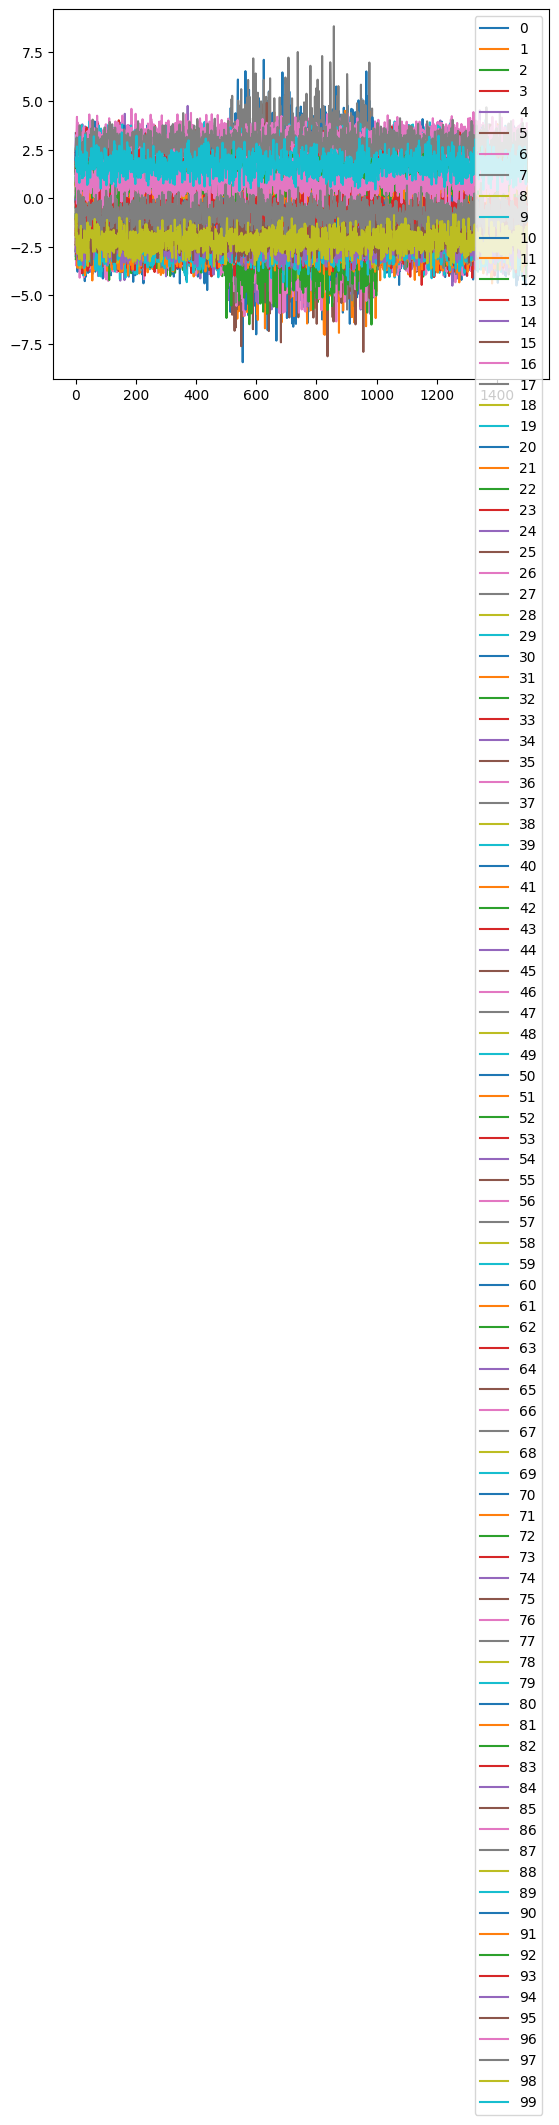

In [146]:
pd.DataFrame(X).plot()

In [50]:
from utilsCPD import *
import matplotlib.pyplot as plt
from SWCPD import BaseDetector as SWDCP

In [187]:
base_center = list(np.random.uniform(-20, 20, 100))  
random_states = [2020,2021,2022,2023,2024]#,2021,2022,2023,2024,2025]
n_clusters = 4
n_samples = 1500
varying_features = [0,25,37,2,20,45,1,4,5,6,7,8,10,32,21]

SIGMA = [0.1,0.3,0.5]

METRICS = []
#METRICS[rs] = {}
RUN_STATS = {}
RUN_STATS_KCP = {}
for sigma in SIGMA:
    RUN_STATS[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[], 'DD':[]}
    RUN_STATS_KCP[str(sigma)] = {'F1 & AUC & FP':[],'Covering':[], 'DD':[]}
    for rs in random_states:
        print(rs,sigma)
        #RUN_STATS[sigma] = {}
        X, y, centers = make_dynamic_blobs_var(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=sigma, 
            var_offset_range=(2*sigma, 2*sigma+1), 
            random_state=rs, distribution=["normal"] * 50 + ["exponential"] *50,
        )
        df, GroundTruth = X, np.where(np.diff(y)!=0)[0]+1
        print(GroundTruth)
        detector = SWDCP(data=df,window_length=100,max_history=100,significance=0.05,use_cuda=False)
        print(detector.device)
        detector.process_dataloader(p=2,n_theta=5000,explanations=False)
        TMP = {}
        for margin in [30,50]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])
        #print(RUN_STATS)


        algo_c = rpt.KernelCPD(kernel="rbf", min_size=1).fit(df) 
        penalty_value = 1.0# beta
        cps_KCPA_PELT = algo_c.predict(pen=penalty_value)
        cps = np.array(cps_KCPA_PELT)[:-1]
        detector.change_points['loc'] = cps
        TMP = {}
        for margin in [30,50]:
            TMP[str(margin)] = f_measure({'0':GroundTruth},detector.change_points['loc'],margin=margin)
        RUN_STATS_KCP[str(sigma)]['F1 & AUC & FP'].append(TMP)
        RUN_STATS_KCP[str(sigma)]['Covering'].append(covering({'0':GroundTruth},detector.change_points['loc'],n_obs=df.shape[0]))
        RUN_STATS_KCP[str(sigma)]['DD'].append(detection_delay(GroundTruth,detector.change_points['loc'])[1])
        #print(RUN_STATS)
    #METRICS.append(RUN_STATS)
RUN_STATS


2020 0.1
[ 375  750 1125]
cpu


 23%|██▎       | 317/1401 [00:01<00:04, 228.39it/s]

Change detected at: 378 
Initiate new segment


 51%|█████▏    | 720/1401 [00:03<00:03, 217.23it/s]

Change detected at: 783 
Initiate new segment


...

Change detected at: 406 
Initiate new segment


 78%|███████▊  | 1094/1401 [00:05<00:01, 207.01it/s]

Change detected at: 1154 
Initiate new segment


100%|██████████| 1401/1401 [00:06<00:00, 207.05it/s]


{'0.1': {'F1 & AUC & FP': [{'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)}],
  'Covering': [0.9463664983053589,
   0.9415746640612832,
   0.9487922095749792,
   0.9304511070858237,
   0.9416227714136397],
  'DD': [14.0,
   15.333333333333334,
   13.333333333333334,
   18.333333333333332,
   15.333333333333334]},
 '0.3': {'F1 & AUC & FP': [{'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (0.75, 0.75, 1)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.5714285714285715, 0.5833333333333333, 1),
    '50': (0.8571428571428571, 0.875, 0)},
   {'30': (0.8571428571428571, 0.875, 0),
    '50': (0.8571428571428571, 0.875, 0)}],
  'Covering': [0.889716909008672,
   0.6720938862114181,
   0.8919875223594627,
   0.6966056790578268,
   0.7125284164603232],
  'DD': [

In [ ]:
k1,k2, k3= RUN_STATS.keys()


grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key, k3
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))

grouped = {}

for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key, k3
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


#### 
print("########## Fales Positives ############")

grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))




30 0.75 0.0
50 1.0 0.0
30 0.74 0.09
50 0.9 0.09
30 0.35 0.12
50 0.88 0.0
########## Fales Positives ############
30 1.0 1 1
50 0.0 0 0
30 0.8 0 1
50 0.2 0 1
30 1.8 1 2
50 0.0 0 0


In [189]:
k1,k2, k3= RUN_STATS.keys()


grouped = {}

for d in RUN_STATS_KCP[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[1])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


grouped = {}

for d in RUN_STATS_KCP[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key, k3
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))

grouped = {}

for d in RUN_STATS_KCP[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key, k3
        grouped[key].append(value[1])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.round(np.std(v),2))


#### 
print("########## Fales Positives ############")

grouped = {}

for d in RUN_STATS_KCP[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key

#print(k1,pd.DataFrame(grouped).describe())
for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS_KCP[k2]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))


grouped = {}

for d in RUN_STATS_KCP[k3]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = []  # Initialize a list for each key
        grouped[key].append(value[2])  # Append the value to the corresponding key


for k,v in grouped.items():
    print(k,np.round(np.mean(v),2),np.min(v),np.max(v))



30 0.55 0.01
50 0.55 0.01
30 0.8 0.1
50 0.8 0.1
30 0.93 0.08
50 0.93 0.08
########## Fales Positives ############
30 32.4 24 38
50 28.6 18 34
30 3.4 0 5
50 2.6 0 5
30 0.8 0 2
50 0.4 0 2


In [200]:
k1,k2, k3= RUN_STATS.keys()


grouped = {}

for d in RUN_STATS[k1]['F1 & AUC & FP']:
    for key, value in d.items():
        if key not in grouped:
            grouped[key] = {'AUC':[],'COV':[],'FP':[],'DD':[]}  # Initialize a list for each key
        grouped[key]['AUC'].append(value[1])
        grouped[key]['FP'].append(value[2]) 

    grouped[key]['DD'] =RUN_STATS[k1]['DD']
    grouped[key]['COV'] =RUN_STATS[k1]['Covering'] 
    



# 
grouped

{'30': {'AUC': [0.75, 0.75, 0.75, 0.75, 0.75],
  'COV': [],
  'FP': [1, 1, 1, 1, 1],
  'DD': []},
 '50': {'AUC': [1.0, 1.0, 1.0, 1.0, 1.0],
  'COV': [0.9463664983053589,
   0.9415746640612832,
   0.9487922095749792,
   0.9304511070858237,
   0.9416227714136397],
  'FP': [0, 0, 0, 0, 0],
  'DD': [14.0,
   15.333333333333334,
   13.333333333333334,
   18.333333333333332,
   15.333333333333334]}}

In [206]:
RUN_STATS

{'0.1': {'F1 & AUC & FP': [{'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)}],
  'Covering': [0.9463664983053589,
   0.9415746640612832,
   0.9487922095749792,
   0.9304511070858237,
   0.9416227714136397],
  'DD': [14.0,
   15.333333333333334,
   13.333333333333334,
   18.333333333333332,
   15.333333333333334]},
 '0.3': {'F1 & AUC & FP': [{'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.75, 0.75, 1), '50': (0.75, 0.75, 1)},
   {'30': (0.75, 0.75, 1), '50': (1.0, 1.0, 0)},
   {'30': (0.5714285714285715, 0.5833333333333333, 1),
    '50': (0.8571428571428571, 0.875, 0)},
   {'30': (0.8571428571428571, 0.875, 0),
    '50': (0.8571428571428571, 0.875, 0)}],
  'Covering': [0.889716909008672,
   0.6720938862114181,
   0.8919875223594627,
   0.6966056790578268,
   0.7125284164603232],
  'DD': [

In [240]:
grouped = {}
for k in RUN_STATS.keys():
    print(k)
    AUC, COV, FP,DD = [],RUN_STATS[k]['Covering'],[],RUN_STATS[k]['DD']
    for d in RUN_STATS[k]['F1 & AUC & FP']:
       AUC.append(d['50'][1])
       FP.append(d['50'][2])
    print(f"AUC {np.mean(AUC):.4f} +- {np.std(AUC):.4f}|FP {np.mean(FP):.4f} ({np.min(FP):.2f},{np.max(FP):.2f})|Cov {np.mean(COV):.4f}+-{np.std(COV):.4f}|DD {np.mean(DD):.4f}+-{np.std(DD):.4f}")

print("######################### KCP")
grouped = {}
for k in RUN_STATS_KCP.keys():
    print(k)
    AUC, COV, FP,DD = [],RUN_STATS_KCP[k]['Covering'],[],RUN_STATS_KCP[k]['DD']
    for d in RUN_STATS_KCP[k]['F1 & AUC & FP']:
       AUC.append(d['50'][1])
       FP.append(d['50'][2])
    print(f"AUC {np.mean(AUC):.4f} +- {np.std(AUC):.4f}|FP {np.mean(FP):.4f} ({np.min(FP):.2f},{np.max(FP):.2f})|Cov {np.mean(COV):.4f}+-{np.std(COV):.4f}|DD {np.mean(DD):.4f}+-{np.std(DD):.4f}")


0.1
AUC 1.0000 +- 0.0000|FP 0.0000 (0.00,0.00)|Cov 0.9418+-0.0063|DD 15.2667+-1.7179
0.3
AUC 0.9000 +- 0.0935|FP 0.2000 (0.00,1.00)|Cov 0.7726+-0.0974|DD 29.9667+-6.2631
0.5
AUC 0.8750 +- 0.0000|FP 0.0000 (0.00,0.00)|Cov 0.6885+-0.0086|DD 35.2000+-4.9457
######################### KCP
0.1
AUC 0.5487 +- 0.0056|FP 28.6000 (18.00,34.00)|Cov 0.6541+-0.0460|DD 107.2138+-17.9546
0.3
AUC 0.7960 +- 0.1046|FP 2.6000 (0.00,5.00)|Cov 0.8989+-0.0748|DD 51.9274+-32.6759
0.5
AUC 0.9333 +- 0.0816|FP 0.4000 (0.00,2.00)|Cov 0.9856+-0.0185|DD 8.2000+-10.5875


|$\sigma_{base}$|$\sigma_{change}$|Method|AUC|Covering|FP|DD|
|---|---|---|---|---|---|---|
|$0.1$|$(0.2,1.2)$|SWCPD|$1.0 \pm 0.0$|$0.94 \pm 0.01$|$0.0$ (0,0)|$15.26 \pm 1.8$|
|$0.1$|$(0.2,1.2)$|KCP|$0.55 \pm 0.01$|$0.65 \pm 0.04$|$28.6$ (18,34)|$107.21 \pm 17.95$|
|$0.3$|$(0.6,1.6)$|SWCPD|$0.9 \pm 0.01$|$0.77 \pm 0.1$|$0.2$ (0,1)|$29.9 \pm 6.3$|
|$0.3$|$(0.6,1.6)$|KCP|$0.79 \pm 0.1$|$0.89 \pm 0.04$|$2.6$ (0,5)|$51.9 \pm 32.67$|
|$0.5$|$(1,2)$|SWCPD|$0.88\pm 0.0$|$0.69 \pm 0.01$|$0.0$ (0,0)|$35.2 \pm 4.9$|
|$0.5$|$(1,2)$|KCP|$0.93 \pm 0.01$|$0.98 \pm 0.04$|$0.4$ (0,2)|$8.2 \pm 10.95$|
